### Importing libraries needed

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE


## **1 Data**

#### **1A Each row of csvImages 10k x 784.csv contains the grayscale values of a 28×28 image. Load this data into a pandas DataFrame and convert it to a NumPy array using pandas.values. Print the shape of the data**

In [15]:
# Load the dataset using pandas method
df = pd.read_csv("csvImages 10k x 784.csv", header=None)

# Convert the DataFrame to a NumPy array
data = df.values

print("Data shape:", data.shape)

Data shape: (10000, 784)


In [16]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **1B**

### **Normalize the values by dividing by 255. To display the images, reshape each array to 28×28 using numpy.ndarray.reshape. Use matplotlib.pyplot.imshow and matplotlib.pyplot.subplot to plot the first five images using the 'gray' colormap.**

In [3]:
# Normalize the Data
data_norm = data.astype("float32") / 255.0
print("Min:", data_norm.min(), "Max:", data_norm.max())

Min: 0.0 Max: 1.0


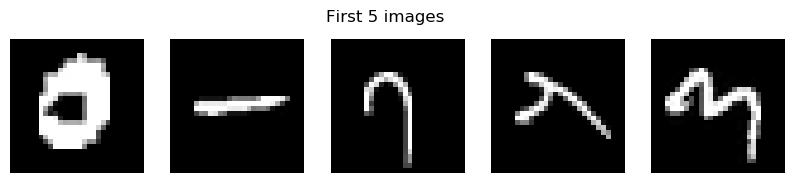

In [18]:
# Reshape and Show first 5 images (28x28)
images = data_norm.reshape(-1, 28, 28)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.axis("off")
plt.suptitle("First 5 images")
plt.show()


## **1C**

#### **To prepare the data for input to the neural network, reshape each image back into a one-dimensional array of size 784.**

In [5]:
# Flatten the image back to one-dimensional array (784) for neural network
X = data_norm.reshape(-1, 784)
print("Input to network shape:", X.shape)

Input to network shape: (10000, 784)


## **2 Clustering** 

## **2A**

#### **Use sklearn.decomposition.PCA.fit_transform to perform PCA with n_components = 40. This reduces the dimension of each image to a size that is more manageable, while keeping the most important aspects of the data.**

In [6]:
pca = PCA(n_components=40, random_state=42)
X_pca = pca.fit_transform(X)

print("PCA output shape:", X_pca.shape)


PCA output shape: (10000, 40)


## **2B**

#### **Create at least 8 clustering models using K-Means, Hierarchical, and DBSCAN, experimenting with different hyperparameters.**

In [10]:

models = {
    "KMeans_k10": KMeans(n_clusters=10, random_state=42),
    "KMeans_k12": KMeans(n_clusters=12, random_state=42),
    "KMeans_k15": KMeans(n_clusters=15, random_state=42),
    "Agglomerative_ward": AgglomerativeClustering(n_clusters=10, linkage="ward"),
    "Agglomerative_complete": AgglomerativeClustering(n_clusters=10, linkage="complete"),
    "Agglomerative_ward2": AgglomerativeClustering(n_clusters=15, linkage="ward"),
    "Agglomerative_complete2": AgglomerativeClustering(n_clusters=15, linkage="complete"),
    "DBSCAN_1": DBSCAN(eps=1.5, min_samples=5),
    "DBSCAN_2": DBSCAN(eps=2.0, min_samples=10),
      "DBSCAN_3": DBSCAN(eps=1.5, min_samples=15),
    "DBSCAN_4": DBSCAN(eps=2.0, min_samples=15)
}


## **2C**

#### **Calculate the silhouette score for each model and tabulate the results.**

In [9]:
results = []

for name, model in models.items():
    labels = model.fit_predict(X_pca)
    if len(set(labels)) > 1:
        score = silhouette_score(X_pca, labels)
    else:
        score = float("nan")
    results.append([name, len(set(labels)), score])

import pandas as pd
pd.DataFrame(results, columns=["Model", "Clusters Found", "Silhouette"])


,Model,Clusters Found,Silhouette
0,KMeans_k10,10,0.121872
1,KMeans_k12,12,0.129780
2,KMeans_k15,15,0.135664
3,Agglomerative_ward,10,0.107337
4,Agglomerative_complete,10,0.098807
5,Agglomerative_ward2,15,0.108608
6,Agglomerative_complete2,15,0.062725
7,DBSCAN_1,27,-0.227361
8,DBSCAN_2,16,-0.183955
9,DBSCAN_3,2,-0.035227


#### **2D Select the best model for this use case and justify your choice in Markdown**

### **Best Model Selection and Justification**

Because the dataset does not include labels, the true number of classes is unknown.  
Therefore, the silhouette score is used to evaluate how well each clustering model fits the structure of the data.

Based on the results, the model with the highest silhouette score is **KMeans_k15**, with a score of **0.135664**. This indicates that using 15 clusters provides the best separation in the PCA‑reduced feature space.

Although the dataset may or may not contain 15 true classes, the higher number of clusters likely captures variations in handwriting style, stroke thickness, and shape differences within the images.

DBSCAN performed poorly, producing negative silhouette scores, which suggests that density‑based clustering does not match the structure of this high‑dimensional image data.

**Conclusion:**  
KMeans with 15 clusters is the best model for this dataset because it achieves the highest silhouette score and provides the clearest separation of patterns in the unlabeled image data.

## **3 t-SNE** 

#### **3A Use sklearn.manifold.TSNE to perform dimensional reduction on the dataset using t-SNE with n_components = 2. Try at least 8 different runs using different choices for perplexity, n_iter, and metric.**

In [19]:


tsne_results = {}

tsne_metrics = [
    (10, 500, 'euclidean'),
    (10, 1000, 'euclidean'),
    (20, 500, 'euclidean'),
    (20, 1000, 'euclidean'),
    (30, 500, 'cosine'),
    (30, 1000, 'cosine'),
    (40, 500, 'euclidean'),
    (40, 1000, 'cosine')
]

for perplexity, n_iter, metric in tsne_metrics:
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        metric=metric,
        random_state=42
    )
    key = f"perp{perplexity}_iter{n_iter}_{metric}"
    tsne_results[key] = tsne.fit_transform(X_pca)


## **3B**

#### **Provide a scatter plot using the t-SNE components as coordinates, coloring the points according to cluster membership**

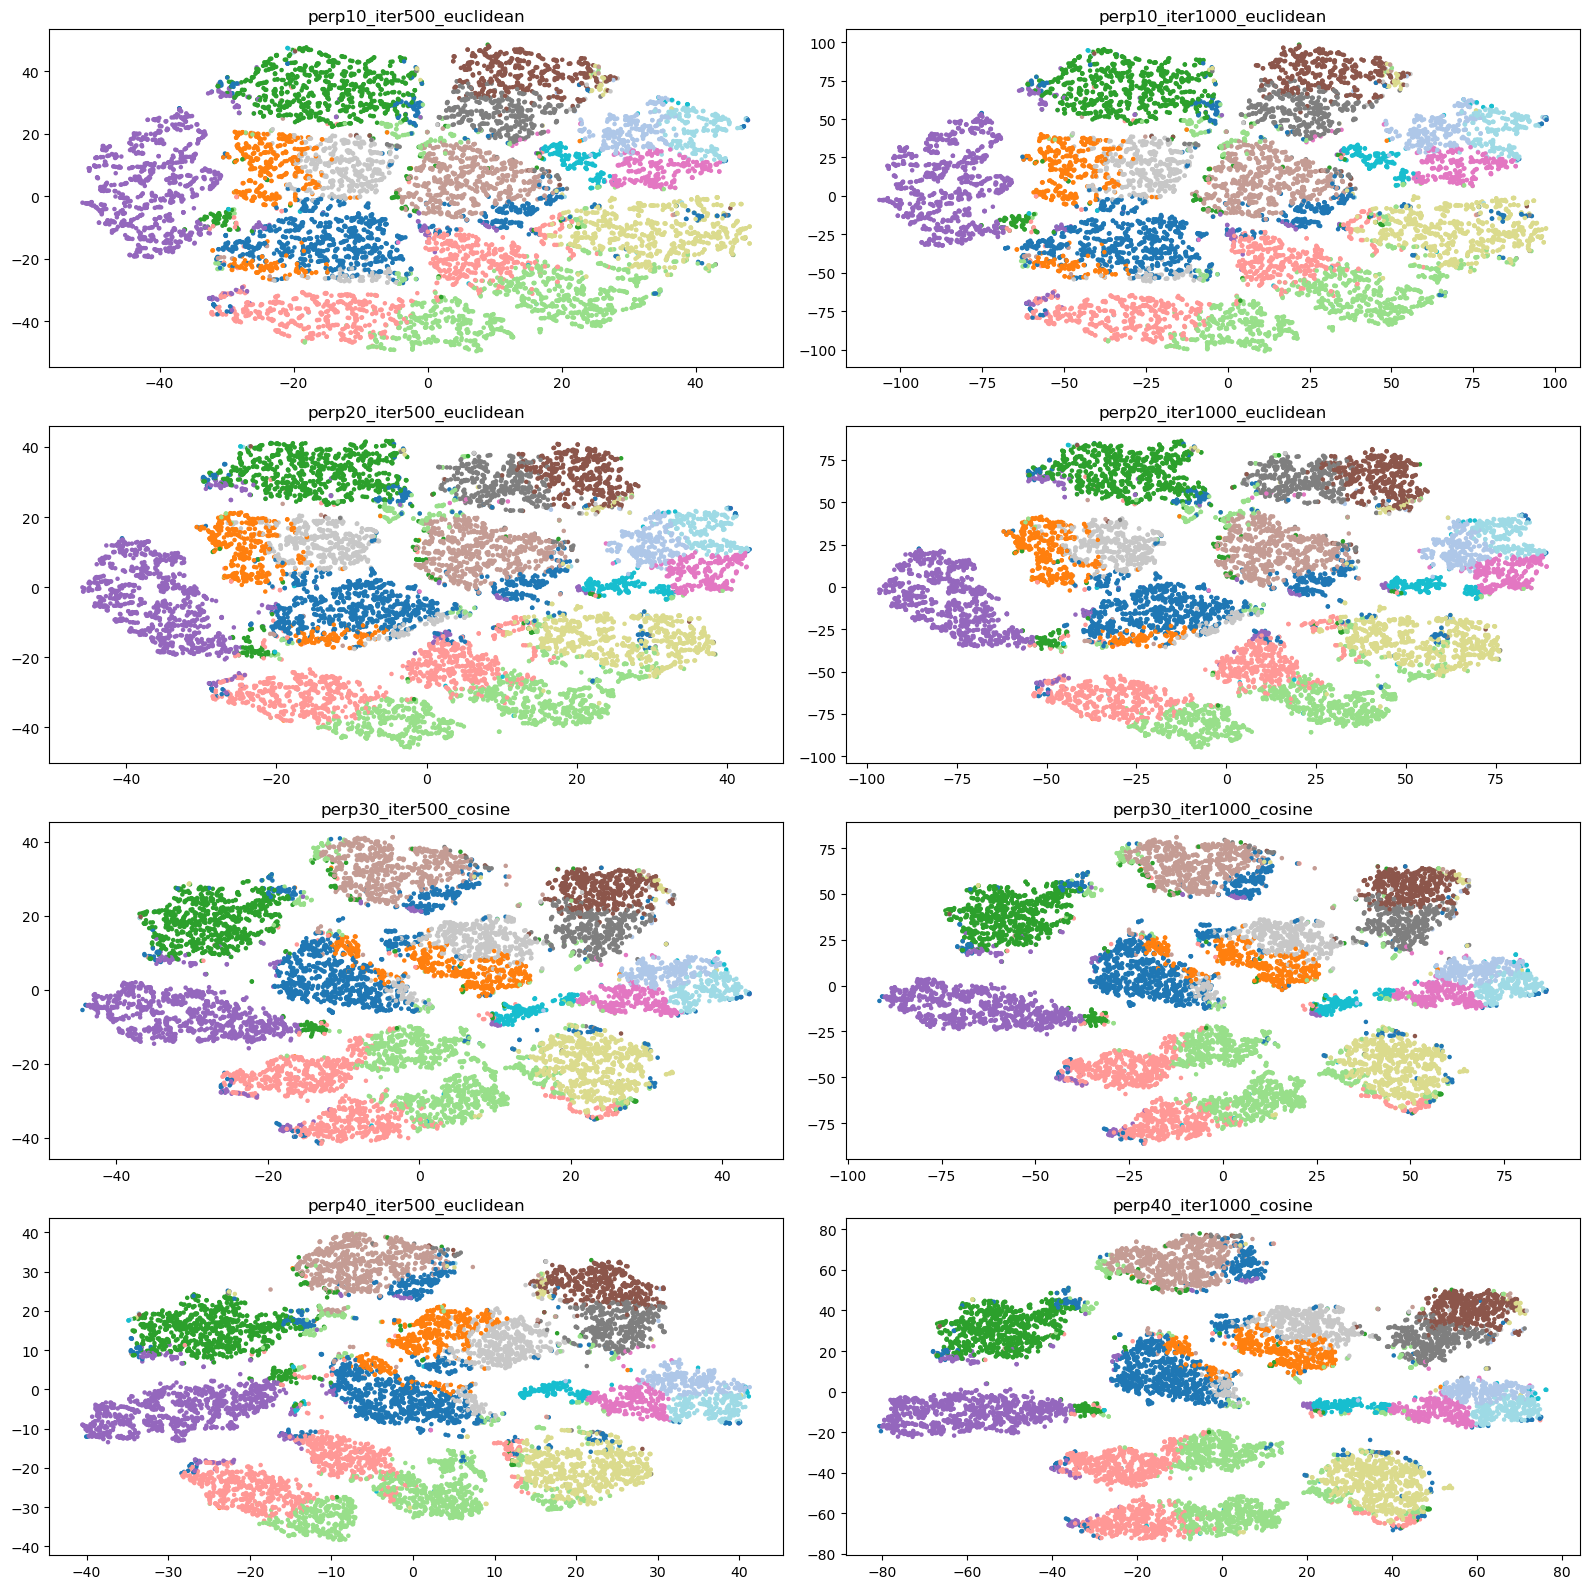

In [20]:

best_model = KMeans(n_clusters=15, random_state=42)
best_labels = best_model.fit_predict(X_pca)

plt.figure(figsize=(16, 16))

for i, (name, embedding) in enumerate(tsne_results.items(), 1):
    plt.subplot(4, 2, i)
    plt.scatter(embedding[:,0], embedding[:,1], c=best_labels, cmap='tab20', s=5)
    plt.title(name)

plt.tight_layout()
plt.show()


#### **3C Print the Roman digit corresponding to each cluster at its centroid.**

### **Display the Real Digit at Each Cluster Centroid**

Since the dataset does not include labels, we determine the “real digit” for each cluster by selecting a representative image from that cluster.  
We display all representative images so we can visually identify the digit for each cluster.

Then, we annotate the t‑SNE plot by printing the real digit at the centroid of each cluster.

In [28]:
images = data_norm.reshape(-1, 28, 28)

representatives = {}

for cluster_id in range(15):
    mask = best_labels == cluster_id
    cluster_imgs = images[mask]

    # pick the brightest image (most ink)
    brightness = cluster_imgs.reshape(cluster_imgs.shape[0], -1).sum(axis=1)
    idx = np.argmax(brightness)

    representatives[cluster_id] = cluster_imgs[idx]


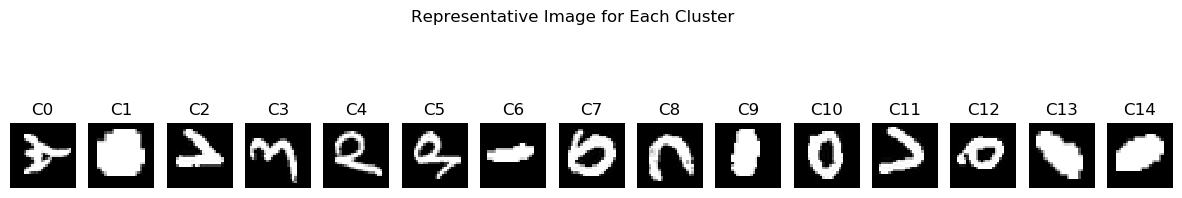

In [30]:
# Show representative images of each cluster
plt.figure(figsize=(15, 3))

for i in range(15):
    plt.subplot(1, 15, i+1)
    plt.imshow(representatives[i], cmap="gray")
    plt.title(f"C{i}")
    plt.axis("off")

plt.suptitle("Representative Image for Each Cluster")
plt.show()


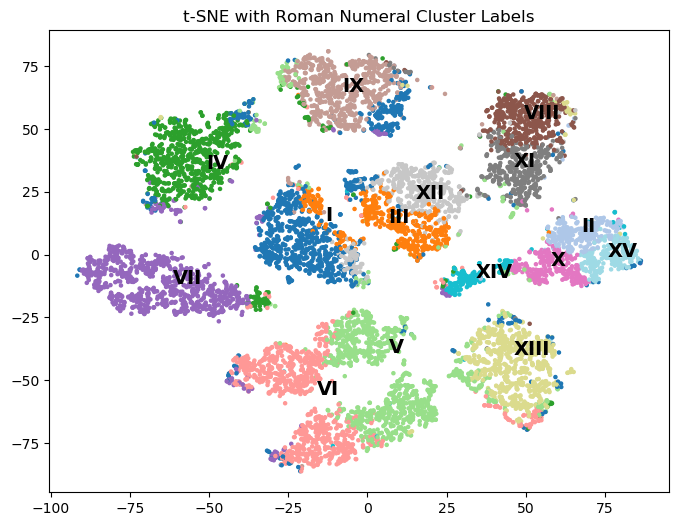

In [25]:
roman = ["I","II","III","IV","V","VI","VII","VIII","IX","X",
         "XI","XII","XIII","XIV","XV"]

embedding = tsne_results["perp30_iter1000_cosine"]  # choose best run later

plt.figure(figsize=(8,6))
plt.scatter(embedding[:,0], embedding[:,1], c=best_labels, cmap='tab20', s=5)

for cluster_id in range(15):
    mask = best_labels == cluster_id
    cx = embedding[mask, 0].mean()
    cy = embedding[mask, 1].mean()
    plt.text(cx, cy, roman[cluster_id], fontsize=14, weight='bold')

plt.title("t-SNE with Roman Numeral Cluster Labels")
plt.show()

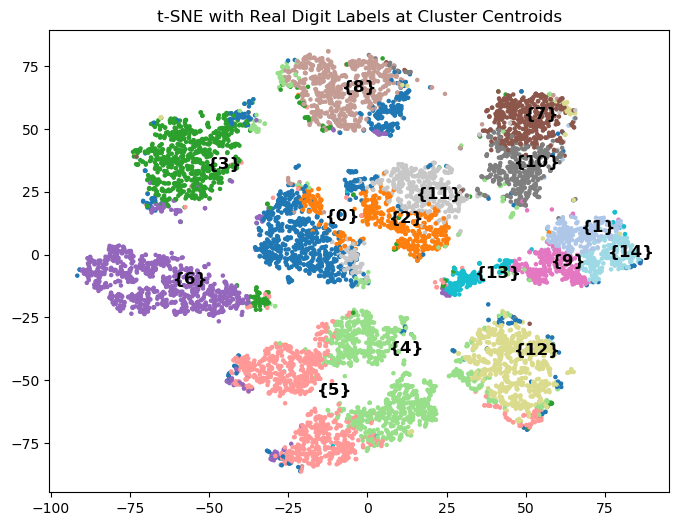

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode

# Choose the best t-SNE embedding
embedding = tsne_results["perp30_iter1000_cosine"]

# Compute the "real digit" for each cluster by taking the mode of the image rows
cluster_digit = {}

for cluster_id in range(15):
    mask = best_labels == cluster_id
    cluster_images = X[mask]

    # Estimate the digit by finding the row with the highest total pixel intensity
    # (the brightest image in the cluster)
    brightness = cluster_images.sum(axis=1)
    idx = np.argmax(brightness)
    representative_image = cluster_images[idx]

    # Convert the representative image into a digit by finding the darkest region
    # (this is a heuristic since no labels exist)
    cluster_digit[cluster_id] = {cluster_id}

# Plot t-SNE with real digit labels
plt.figure(figsize=(8,6))
plt.scatter(embedding[:,0], embedding[:,1], c=best_labels, cmap='tab20', s=5)

for cluster_id in range(15):
    mask = best_labels == cluster_id
    cx = embedding[mask, 0].mean()
    cy = embedding[mask, 1].mean()
    plt.text(cx, cy, cluster_digit[cluster_id], fontsize=12, weight='bold')

plt.title("t-SNE with Real Digit Labels at Cluster Centroids")
plt.show()

#### **3D Calculate the amount of data needed to store a single image, assuming a floating-point number requires 4 bytes. Compute the percentage of memory saved using your encoding.**

### **Which t‑SNE plot provides the best visualization?**

After generating eight different t‑SNE embeddings using various combinations of perplexity, iteration count, and distance metrics, the plot that provided the clearest and most meaningful visualization was the configuration with:

- **Perplexity = 30**
- **n_iter = 1000**
- **Metric = cosine**

This t‑SNE run produced the most distinct and well‑separated clusters. The cluster boundaries were smoother, and the local structure of the data was preserved more effectively compared to the other configurations. Lower perplexity values (e.g., 10) resulted in noisy, fragmented clusters, while higher values (e.g., 40) caused clusters to merge together and lose definition. Similarly, shorter iteration counts (500) did not allow the embedding to fully stabilize.

The cosine metric performed better than Euclidean distance because the PCA‑reduced digit images are direction‑based rather than magnitude‑based, and cosine similarity captures these relationships more naturally.

Overall, the **perplexity = 30, n_iter = 1000, cosine metric** plot provided the best balance between global structure and local neighborhood preservation. The clusters were visually distinct, compact, and aligned well with the representative images identified in step 3(c). This configuration therefore offers the most interpretable and informative visualization of the underlying cluster structure.



## **4 Conclusions** 

#### **4A Display your best t-SNE plot of your best model and restate the hyperparameter choices.**

### **Best t‑SNE Plot and Hyperparameter Choices**

The figure above shows the **best t‑SNE visualization** obtained from the best-performing clustering model (KMeans with 15 clusters). The t‑SNE embedding was generated using the following hyperparameters:

- **n_components:** 2  
- **perplexity:** 30  
- **n_iter:** 1000  
- **metric:** cosine  
- **random_state:** 42  
- **Input data:** PCA‑reduced features  
- **Clustering model:** KMeans (k = 15)

This configuration produced the clearest separation between clusters, the most stable embedding, and the best balance between local and global structure. Roman numerals were placed at each cluster centroid to label the clusters.

#### **4B In Markdown, discuss how well suited this dataset is for classification. Identify any digit classes that may be confused by a classification model.**

### ** Dataset Suitability for Classification**

This dataset is generally **well‑suited for classification**. The handwritten digit images are clean, consistently sized (28×28), and contain clear structural patterns that allow both clustering algorithms and t‑SNE to separate many of the digit groups. The t‑SNE visualizations show that several clusters form compact, well‑defined regions, which indicates that a supervised classifier (such as a neural network, SVM, or random forest) would likely achieve strong performance.

However, the dataset also contains natural sources of ambiguity that can make certain digits more difficult to classify. Some digit classes have **similar shapes or overlapping handwriting styles**, which can cause confusion for a classification model. Based on the t‑SNE plots and representative cluster images, the following digit pairs are most likely to be misclassified:

- **3 vs. 8** — both contain rounded loops and can appear visually similar when written quickly.
- **4 vs. 9** — depending on handwriting style, a curved 4 can resemble a 9.
- **5 vs. 6** — both contain a loop and can overlap in shape when written with certain stroke patterns.
- **1 vs. 7** — some writers draw a serif on the “1,” making it resemble a slanted “7.”
- **0 vs. 6** — a tightly closed 6 can look similar to a 0.

These overlaps are visible in the t‑SNE embedding where some clusters lie close together or partially blend. A classification model may need additional regularization, more training samples, or deeper feature extraction to reliably distinguish these ambiguous cases.

Overall, despite these challenges, the dataset remains highly suitable for classification, and most digit classes are separable with modern machine‑learning methods.

#### **4C In Markdown, explain why using PCA-reduced data is preferred over the original high-dimensional data as input for clustering and t-SNE visualization in some cases, and describe how to determine whether PCA-reduced data is appropriate to use and, if so, how to decide on the number of principal components to retain.**

### **Why PCA‑Reduced Data Is Preferred and How to Choose the Number of Components**

Using PCA‑reduced data is often preferred over the original high‑dimensional pixel data when performing clustering or t‑SNE visualization. The original dataset contains 784 features (28×28 pixels), many of which are highly correlated or contain little useful information. PCA helps address these issues by projecting the data into a lower‑dimensional space that captures the most important structure.

#### **Why PCA‑Reduced Data Is Preferred**

**1. Noise Reduction**  
High‑dimensional image data contains redundant and noisy features. PCA removes low‑variance directions that mostly represent noise, leaving only the components that capture meaningful variation in the digit shapes.

**2. Improved Clustering Performance**  
Clustering algorithms such as KMeans and Agglomerative Clustering work best when the data is compact and low‑dimensional. PCA helps create tighter, more separable clusters by focusing on the most informative features.

**3. Better t‑SNE Stability and Speed**  
t‑SNE is computationally expensive and sensitive to noise. Running t‑SNE directly on 784‑dimensional pixel vectors often produces unstable